Customer Data Shape: (200, 2)
Elbow plot saved!
Cluster plot saved!

Results:
Optimal K: 4
Silhouette Score: 0.405


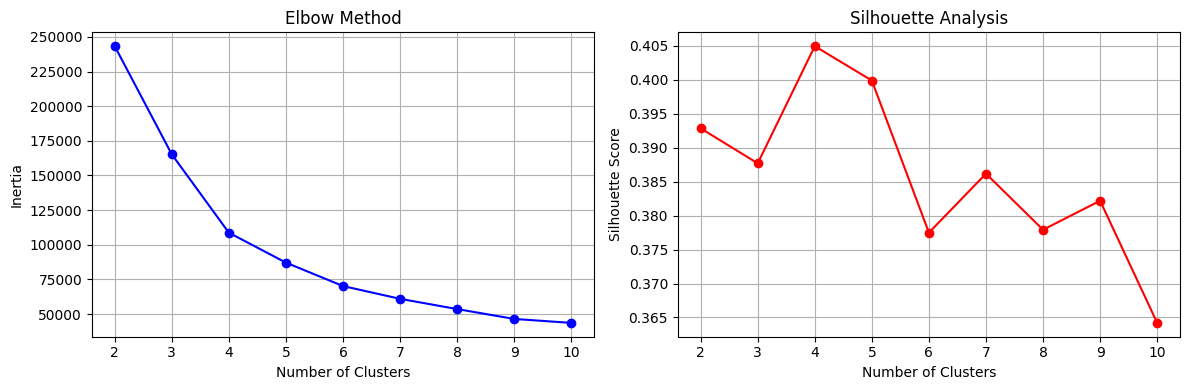

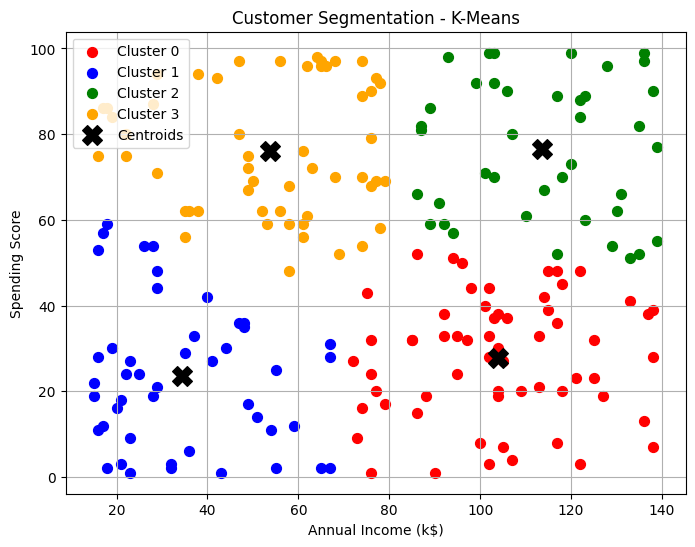

In [1]:
"""
Assignment 1: K-Means Clustering
Customer Segmentation
"""
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Generate sample customer data
np.random.seed(42)
income = np.random.randint(15, 140, 200)
spending = np.random.randint(1, 100, 200)
X = np.column_stack([income, spending])

print("Customer Data Shape:", X.shape)

# Find optimal K using Elbow Method
inertias = []
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))

# Plot Elbow Curve
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(2, 11), inertias, 'bo-')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.grid(True)

plt.tight_layout()
plt.savefig('assignment1_elbow.png')
print("Elbow plot saved!")

# Apply K-Means with K=4
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X)

# Visualize clusters
plt.figure(figsize=(8, 6))
colors = ['red', 'blue', 'green', 'orange']

for i in range(4):
    cluster_points = X[labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                c=colors[i], label=f'Cluster {i}', s=50)

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            c='black', marker='X', s=200, label='Centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.title('Customer Segmentation - K-Means')
plt.legend()
plt.grid(True)
plt.savefig('assignment1_clusters.png')
print("Cluster plot saved!")

print("\nResults:")
print(f"Optimal K: 4")
print(f"Silhouette Score: {silhouette_score(X, labels):.3f}")